<a href="https://colab.research.google.com/github/mskalaiwani00294-lang/Python-Social-Media-Engagement-Data-Analysis/blob/main/Python_Social_Media_Engagement_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the social_media_engagement_5000.csv dataset
df = pd.read_csv("https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/social_media_engagement_5000.csv")

df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
df.shape

(5000, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64



# **Data Cleaning**

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate'],
      dtype='object')

In [ ]:
#Convert date columns to datetime
df.loc[:, "posted_at"] = pd.to_datetime(
    df["posted_at"], errors="coerce"
)

/tmp/ipykernel_845/1492980354.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df.loc[:, "posted_at"] = pd.to_datetime(


In [ ]:
df = df.copy()

# Fill missing age values with median
df["age"] = df["age"].fillna(df["age"].median())

# Convert age to integer
df["age"] = df["age"].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               5000 non-null   int64  
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [ ]:
df.isnull().mean()*100.

,0
user_id,0.0
age,0.0
gender,3.0
country,0.0
post_id,0.0
post_type,0.0
post_category,0.0
likes,3.0
comments,3.0
shares,3.0


In [ ]:
#hendle Missing Values
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_845/659612010.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [ ]:
df[["age"]].describe()

,age
count,5000.000000
mean,38.440400
std,14.687151
min,13.000000
25%,26.000000
50%,38.000000
75%,51.000000
max,64.000000


In [ ]:
#The minimum value in the age column is 0, so I will change it using this method.
df.loc[(df["age"] < 13) | (df["age"] > 100), "age"] = np.nan
df.loc[df["age"] == 0, "age"] = pd.NA
df["age"] = df["age"].fillna(df["age"].median())

print(df["age"].isnull().sum())

0


In [ ]:
df[["age"]].describe()

,age
count,5000.000000
mean,38.440400
std,14.687151
min,13.000000
25%,26.000000
50%,38.000000
75%,51.000000
max,64.000000


In [ ]:
#dulicate handling
df.duplicated().sum()

np.int64(0)

# **Data Formatting**


In [ ]:
#fix incorrect data types
df["likes"] = pd.to_numeric(df["likes"], errors="coerce")
df["comments"] = pd.to_numeric(df["comments"], errors="coerce")
df["shares"] = pd.to_numeric(df["shares"], errors="coerce")

df["engagement_rate"] = pd.to_numeric(
    df["engagement_rate"], errors="coerce"
)

In [ ]:
#Standardize Gender
df["gender"].value_counts()

,count
gender,
Male,1849
Other,1581
Female,1570


In [ ]:
df["gender"]=df["gender"].str.strip().str.lower()

In [ ]:
df["gender"].value_counts()

,count
gender,
male,1849
other,1581
female,1570


In [ ]:
#Correct unrealistic values in likes, comments, shares
df.loc[df["likes"] < 0, "likes"] = np.nan
df.loc[df["comments"] < 0, "comments"] = np.nan
df.loc[df["shares"] < 0, "shares"] = np.nan



In [ ]:
for col in ["likes", "comments", "shares"]:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.loc[(df["age"] < 13) | (df["age"] > 100), "age"] = np.nan

In [ ]:
df[["likes", "comments", "shares"]].describe()

,likes,comments,shares
count,5000.000000,5000.000000,5000.0000
mean,10106.997400,1502.039800,1002.9106
std,5702.293017,856.393312,570.8552
min,10.000000,0.000000,0.0000
25%,5235.000000,792.000000,511.0000
50%,10105.500000,1497.000000,1012.0000
75%,14959.000000,2235.250000,1483.0000
max,19998.000000,2999.000000,1999.0000


In [ ]:
#Feature Cleaning
#Extract hashtag count
df["hashtag_count"] = df["hashtags"].fillna("").str.count("#")
# Clean sentiment labels
df["sentiment"] = df["sentiment"].str.strip().str.lower()

In [ ]:
df[["hashtags", "hashtag_count"]].head()

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1


# **Data Exploration using Pandas**

In [ ]:
#View dataset structure using head(), tail(), shape, and columns.
df.head()


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
df. tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
#Check data types and info with info() and dtypes.
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
#Generate summary statistics using describe()
df.describe().T

,count,mean,min,25%,50%,75%,max,std
user_id,5000.0,54561.8908,10055.0,32309.5,54374.5,77180.5,99963.0,26090.370121
age,5000.0,38.4404,13.0,26.0,38.0,51.0,64.0,14.687151
post_id,5000.0,548042.909,100068.0,322543.5,548077.5,771574.5,999455.0,260646.957267
likes,5000.0,10106.9974,10.0,5235.0,10105.5,14959.0,19998.0,5702.293017
comments,5000.0,1502.0398,0.0,792.0,1497.0,2235.25,2999.0,856.393312
shares,5000.0,1002.9106,0.0,511.0,1012.0,1483.0,1999.0,570.8552
watch_time_sec,5000.0,4014.5032,0.0,2017.75,4034.5,6020.25,7998.0,2308.096459
impression_count,5000.0,50013.7328,105.0,24988.25,49934.5,74662.25,99995.0,28844.939104
posted_at,5000,2022-12-28 13:21:30.240000,2022-01-01 00:00:00,2022-07-03 18:00:00,2022-12-27 00:00:00,2023-06-28 00:00:00,2023-12-31 00:00:00,NaN
follower_count,5000.0,393698.2248,87.0,194480.0,388982.0,589744.25,799533.0,230927.884535


# **Interpretation**

The dataset contains 5,000 social media records covering posts from 2022 to 2023. The average user age is 38.44 years. Posts receive approximately 10,107 likes, 1,502 comments, and 1,003 shares on average. The average impression count is around 50,014, while the average follower count is approximately 393,698. Most numerical variables have mean and median values that are relatively close, indicating fairly balanced distributions. However, the engagement_rate column has a very high maximum value of 191.50 compared with its median of 0.254, suggesting the presence of potential outliers that should be investigated during data cleaning.

Analyze categorical distributions using value_counts(), unique(), and nunique().

In [ ]:
# Find categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'country', 'post_type', 'post_category', 'device_type',
       'sentiment', 'hashtags'],
      dtype='object')


In [ ]:
categorical_columns = [
    'gender',
    'country',
    'post_type',
    'post_category',
    'device_type',
    'sentiment'

]

for col in categorical_columns:
    print("\n---", col, "---")

    print("Value Counts:")
    print(df[col].value_counts())

    print("Unique Values:")
    print(df[col].unique())

    print("Number of Unique Values:")
    print(df[col].nunique())


--- gender ---
Value Counts:
gender
male      1849
other     1581
female    1570
Name: count, dtype: int64
Unique Values:
['female' 'male' 'other']
Number of Unique Values:
3

--- country ---
Value Counts:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64
Unique Values:
['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
Number of Unique Values:
10

--- post_type ---
Value Counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
Unique Values:
['image' 'reel' 'text' 'video']
Number of Unique Values:
4

--- post_category ---
Value Counts:
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64
Unique Values:
['fitness' 'food' 'tech' 'travel' 

In [ ]:
#Create a correlation matrix for numeric fields
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


# Interpretation

  The correlation analysis shows that most numerical variables have very weak relationships. The strongest correlation is between impression_count and engagement_rate (-0.2322), indicating a weak negative relationship. likes and engagement_rate have a very weak positive correlation (0.0935). Overall, the dataset does not show strong linear relationships among the numerical variables.

# **Groupby**

In [ ]:
#Average like by post type
df.groupby("post_type")["likes"].mean()

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [ ]:
#average engagement rate by country
df.groupby("country")["engagement_rate"].mean()


,engagement_rate
country,
Australia,1.324339
Brazil,1.540704
Canada,0.916659
France,1.146402
Germany,0.759000
India,0.655005
Japan,0.769623
UAE,1.112352
UK,0.850966


In [ ]:
#average Likes by post_Category
df.groupby("post_category")["likes"].mean()

,likes
post_category,
education,10126.487322
fashion,9843.356902
fitness,9914.602222
food,10225.522766
lifestyle,10180.559308
music,10205.749606
tech,10171.571429
travel,10196.304167


In [ ]:
#sendtiment performance
df.groupby("sentiment")[
    ["likes", "comments", "shares", "engagement_rate"]
].mean().sort_values(
    "engagement_rate",
    ascending=False
)

,likes,comments,shares,engagement_rate
sentiment,,,,
negative,10208.096875,1516.094792,1007.307292,1.038486
neutral,9923.194499,1528.404060,996.565160,0.991170
positive,10180.062077,1480.650617,1005.086749,0.919744


# Data Wrangling
#

In [ ]:
# Use merge, concat, or join if combining DataFrames
df1 = df[["user_id", "age", "gender"]]
df2 = df[["user_id", "country", "device_type"]]

merged_df = pd.merge(df1, df2, on="user_id")

merged_df.head()

,user_id,age,gender,country,device_type
0,25795,43.0,female,Brazil,mobile
1,10860,33.0,male,Brazil,mobile
2,86820,32.0,female,UK,tablet
3,64886,51.0,other,France,mobile
4,16265,34.0,other,UK,mobile


**Interpretation**

merge() combines two DataFrames using the common column user_id.

In [ ]:

df1 = df.iloc[:100]
df2 = df.iloc[100:200]

combined_df = pd.concat([df1, df2], ignore_index=True)

combined_df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


**Interpretation:**

concat() combines two DataFrames by adding their rows together.

In [ ]:
df1 = df[["user_id", "age"]].set_index("user_id")
df2 = df[["user_id", "country"]].set_index("user_id")

joined_df = df1.join(df2)

joined_df.head()

,age,country
user_id,,
25795,43.0,Brazil
10860,33.0,Brazil
86820,32.0,UK
64886,51.0,France
16265,34.0,UK


**Interpretation:**
join() combines two DataFrames based on their index.

In [ ]:
# create engagement_score
df["engagement_score"] = (
    df["likes"] +
    df["comments"] +
    df["shares"]
)

In [ ]:
df[
    ["likes", "comments", "shares", "engagement_score"]
].head()

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0


**Interpretation:**
Index 4 has the highest engagement score (16,717), while Index 2 has the lowest (6,161).
Higher likes, comments, and shares result in a higher engagement score.

In [ ]:
#log-transformed metrics
df["log_likes"] = np.log1p(df["likes"])
df["log_comments"] = np.log1p(df["comments"])
df["log_shares"] = np.log1p(df["shares"])
df["log_follower_count"] = np.log1p(df["follower_count"])



In [ ]:
df["hashtag_count"] = df["hashtags"].fillna("").str.count("#")
print(df[[
    "engagement_score",
    "log_likes",
    "log_comments",
    "log_shares",
    "log_follower_count",
    "hashtag_count"
]].head())

   engagement_score  log_likes  log_comments  log_shares  log_follower_count  \
0            8522.0   8.855378      5.872118    7.054450           11.311238   
1           16163.0   9.371694      7.865955    7.499977            8.693497   
2            6161.0   8.489411      5.843544    6.862758           13.125925   
3            7482.0   8.585039      6.988413    6.956545           13.081985   
4           16717.0   9.448018      7.914252    7.170888           12.858234   

   hashtag_count  
0              3  
1              1  
2              1  
3              3  
4              1  


# Interpretation
Log transformation reduces the effect of very large values and makes the data easier to analyze.

Engagement Score: Total of likes, comments, and shares. Row 4 has the highest score (16,717).

Log Metrics: Log-transformed likes, comments, shares, and followers reduce the effect of very large values.

Hashtag Count: Shows the number of hashtags used in each post. Rows 0 and 3 use 3 hashtags, while rows 1, 2, and 4 use 1 hashtag.

Overall: These new fields make it easier to analyze engagement, audience size, and hashtag usage.

In [ ]:
#Perform groupby summaries by post_type, country, and sentiment.

#groupby-post Type
post_type_summary = df.groupby("post_type").agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean"),
    avg_engagement=("engagement_rate", "mean")
)
post_type_summary

,avg_likes,avg_comments,avg_shares,avg_engagement
post_type,,,,
image,10104.865277,1525.235766,1019.289495,0.895646
reel,10037.802416,1504.187062,982.042089,0.783047
text,10100.148193,1499.106024,1013.989558,1.064549
video,10188.600000,1479.160000,996.834286,1.122365


In [ ]:
#groupby country
country_summary = df.groupby("country").agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean"),
    avg_engagement=("engagement_rate", "mean")
)


country_summary

,avg_likes,avg_comments,avg_shares,avg_engagement
country,,,,
Australia,10294.124746,1485.803245,1029.693712,1.324339
Brazil,9886.689484,1490.434524,1008.859127,1.540704
Canada,10063.066277,1546.582846,996.245614,0.916659
France,10372.876008,1478.695565,1051.812500,1.146402
Germany,10130.458163,1531.826531,973.379592,0.759000
India,9962.468224,1494.917757,1035.315888,0.655005
Japan,10088.862288,1530.434322,959.351695,0.769623
UAE,10227.487078,1541.214712,989.075547,1.112352
UK,9935.650101,1463.042596,985.681542,0.850966


In [ ]:
#group by sentiment
sentiment_summary = df.groupby("sentiment").agg(
    avg_likes=("likes", "mean"),
    avg_comments=("comments", "mean"),
    avg_shares=("shares", "mean"),
    avg_engagement=("engagement_rate", "mean")
)

sentiment_summary

,avg_likes,avg_comments,avg_shares,avg_engagement
sentiment,,,,
negative,10208.096875,1516.094792,1007.307292,1.038486
neutral,9923.194499,1528.404060,996.565160,0.991170
positive,10180.062077,1480.650617,1005.086749,0.919744


# **Statistical Analysis**

In [ ]:
stats_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate",
    "follower_count"
]

In [ ]:
df[stats_columns].mean()

,0
likes,10106.997400
comments,1502.039800
shares,1002.910600
watch_time_sec,4014.503200
engagement_rate,0.964356
follower_count,393698.224800


In [ ]:
df[stats_columns].median()

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,4034.500000
engagement_rate,0.253896
follower_count,388982.000000


In [ ]:
df[stats_columns].mode().iloc[0]

,0
likes,10105.500000
comments,1497.000000
shares,1012.000000
watch_time_sec,916.000000
engagement_rate,0.006363
follower_count,497502.000000


In [ ]:
df[stats_columns].std()

,0
likes,5702.293017
comments,856.393312
shares,570.855200
watch_time_sec,2308.096459
engagement_rate,5.318029
follower_count,230927.884535


In [ ]:
df[stats_columns].var()

,0
likes,3.251615e+07
comments,7.334095e+05
shares,3.258757e+05
watch_time_sec,5.327309e+06
engagement_rate,2.828143e+01
follower_count,5.332769e+10


In [ ]:
df[stats_columns].quantile(
    [0.25, 0.50, 0.75]
)

,likes,comments,shares,watch_time_sec,engagement_rate,follower_count
0.25,5235.0,792.00,511.0,2017.75,0.145781,194480.00
0.50,10105.5,1497.00,1012.0,4034.50,0.253896,388982.00
0.75,14959.0,2235.25,1483.0,6020.25,0.504794,589744.25


In [ ]:
df[stats_columns].skew()

,0
likes,-0.006894
comments,0.003802
shares,-0.014654
watch_time_sec,-0.018196
engagement_rate,18.781271
follower_count,0.041118


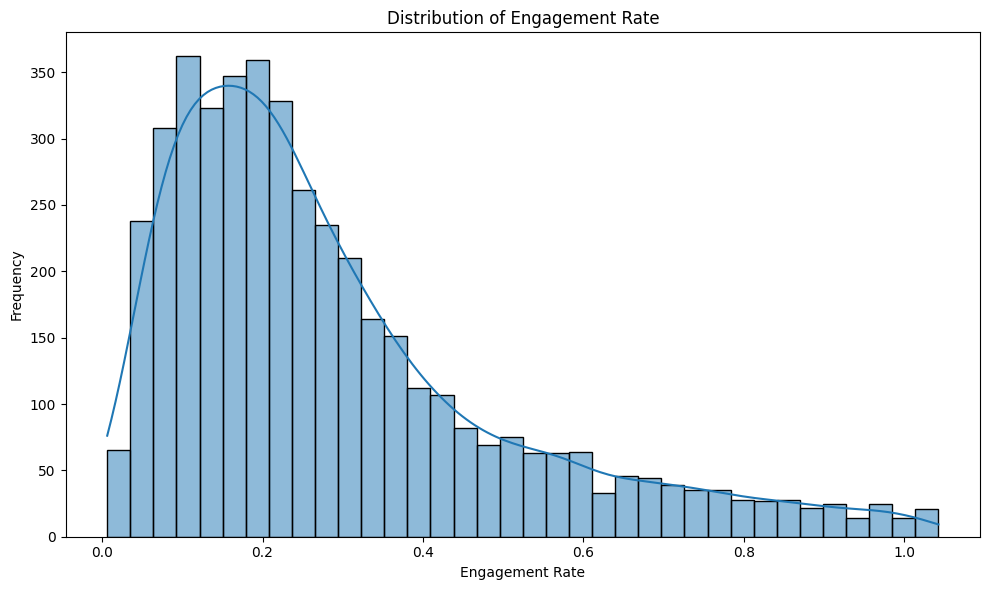

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["engagement_rate"],
    kde=True
)

plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
df[stats_columns].kurtosis()

,0
likes,-1.149992
comments,-1.144375
shares,-1.146857
watch_time_sec,-1.195652
engagement_rate,482.991739
follower_count,-1.189474


In [ ]:
statistics_summary = pd.DataFrame({
    "Mean": df[stats_columns].mean(),
    "Median": df[stats_columns].median(),
    "Mode": df[stats_columns].mode().iloc[0],
    "Std Dev": df[stats_columns].std(),
    "Variance": df[stats_columns].var(),
    "25%": df[stats_columns].quantile(0.25),
    "50%": df[stats_columns].quantile(0.50),
    "75%": df[stats_columns].quantile(0.75),
    "Skewness": df[stats_columns].skew(),
    "Kurtosis": df[stats_columns].kurtosis()
})

statistics_summary

,Mean,Median,Mode,Std Dev,Variance,25%,50%,75%,Skewness,Kurtosis
likes,10106.997400,10105.500000,10105.500000,5702.293017,3.251615e+07,5235.000000,10105.500000,14959.000000,-0.006894,-1.149992
comments,1502.039800,1497.000000,1497.000000,856.393312,7.334095e+05,792.000000,1497.000000,2235.250000,0.003802,-1.144375
shares,1002.910600,1012.000000,1012.000000,570.855200,3.258757e+05,511.000000,1012.000000,1483.000000,-0.014654,-1.146857
watch_time_sec,4014.503200,4034.500000,916.000000,2308.096459,5.327309e+06,2017.750000,4034.500000,6020.250000,-0.018196,-1.195652
engagement_rate,0.964356,0.253896,0.006363,5.318029,2.828143e+01,0.145781,0.253896,0.504794,18.781271,482.991739
follower_count,393698.224800,388982.000000,497502.000000,230927.884535,5.332769e+10,194480.000000,388982.000000,589744.250000,0.041118,-1.189474


**Statistical Interpretation**

Likes: Mean and median are almost equal (~10,106), with skewness near 0, indicating a nearly symmetric distribution.

Comments: Average is ~1,502 and median is ~1,497. Skewness is close to 0, showing a balanced distribution.

Shares: Mean (1,003) and median (~1,012) are close, indicating little skewness.

Watch Time: Mean is ~4,015 seconds and median ~4,035 seconds. The distribution is fairly symmetric.

Engagement Rate: Mean (0.964) is much higher than median (0.254), with very high positive skewness (18.78) and kurtosis (482.99), indicating strong outliers and a highly right-skewed distribution.

Follower Count: Mean (393,698) and median (~388,982) are close, with skewness near 0, suggesting a fairly balanced distribution.


Likes, comments, shares, watch time, and follower count are relatively normally distributed, while engagement rate is highly skewed and contains significant outliers.

In [ ]:
#Engagement Rate: Mean (0.964) is much higher than median (0.254), with very high positive skewness (18.78) and kurtosis(482.99),
# indicating strong outliers and a highly right-skewed distribution.

#I used the IQR (Interquartile Range) method to detect and remove outliers from the "engagement_rate" column.
#Values below the lower limit or above the upper limit were considered outliers and removed

Q1 = df["engagement_rate"].quantile(0.25)
Q3 = df["engagement_rate"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df["engagement_rate"] >= lower_limit) &
    (df["engagement_rate"] <= upper_limit)
]

print(df["engagement_rate"].describe())




count    4422.000000
mean        0.289277
std         0.216163
min         0.006363
25%         0.133880
50%         0.226525
75%         0.373339
max         1.042766
Name: engagement_rate, dtype: float64


**interpretation**:
After removing outliers, the mean engagement rate decreased from 0.964 to 0.289, and the mean and median are now much closer. This indicates that extreme values were successfully reduced, resulting in a more balanced distribution.

# **Data Visualization**

# Matplotlib


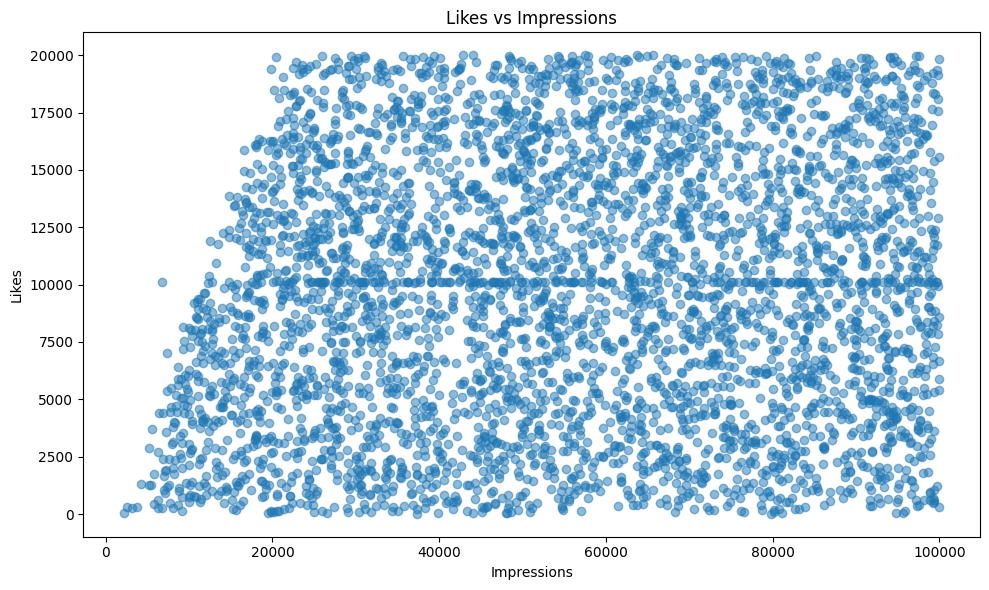

In [ ]:
#Scatter: likes vs impressions
plt.figure(figsize=(10, 6))

plt.scatter(
    df["impression_count"],
    df["likes"],
    alpha=0.5
)

plt.title("Likes vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Likes")

plt.tight_layout()
plt.show()




**Interpretation:**

The scatter plot indicates a weak and unclear relationship between impression count and likes. Likes vary considerably across different levels of impressions, showing that a higher number of impressions does not necessarily lead to higher likes. Therefore, other factors such as content type, audience characteristics, posting time, and engagement behavior may also influence the number of likes.

In [ ]:
#line chat- Daily Engagement Trend
df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")
daily_engagement = df.groupby(
    df["posted_at"].dt.date
)["engagement_score"].mean()




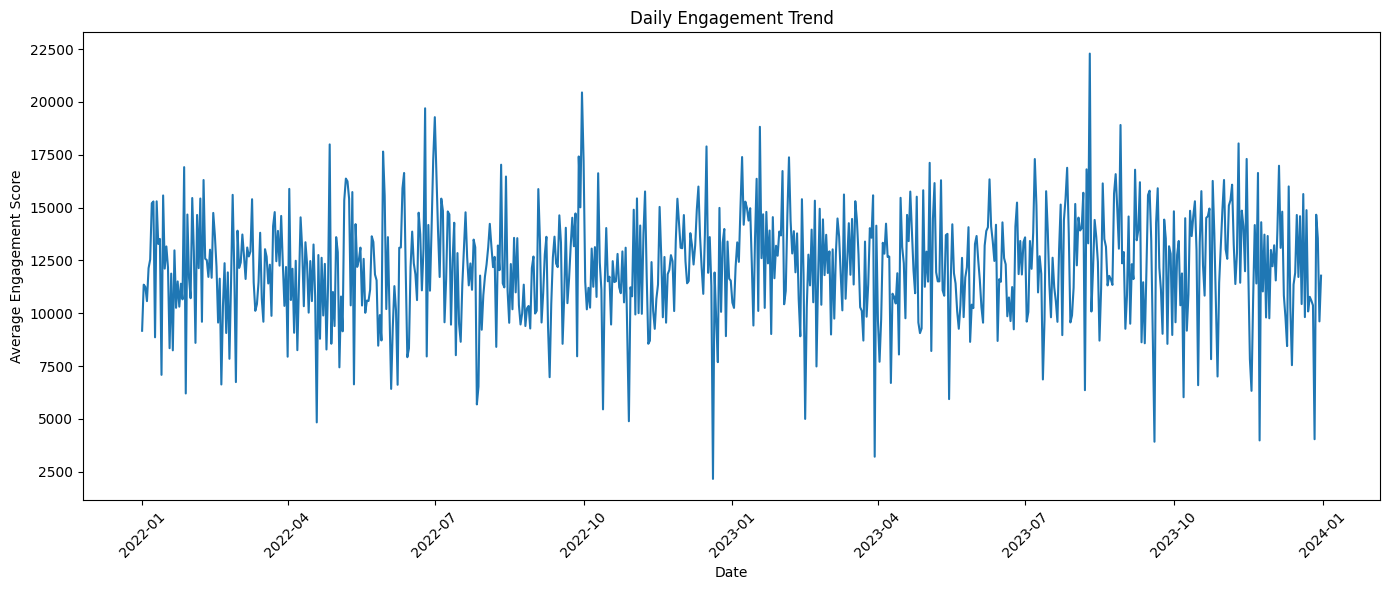

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_engagement.index,
    daily_engagement.values
)

plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Average Engagement Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation:The line chart shows the daily average engagement score over time. The engagement level changes from day to day, with some days showing higher average engagement and other days showing lower engagement. Peaks in the line indicate days with relatively high engagement, while dips indicate days with lower engagement. Overall, the chart helps identify engagement trends, fluctuations, and unusually high or low engagement days.

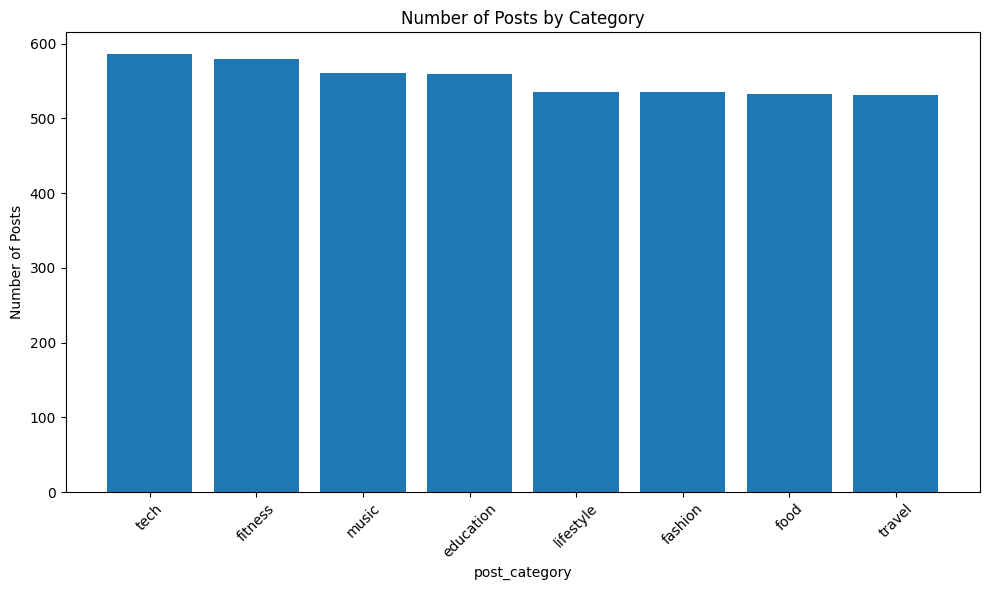

In [ ]:
# Bar: posts by post_category
category_counts = df["post_category"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    category_counts.index,
    category_counts.values
)

plt.title("Number of Posts by Category")
plt.xlabel("post_category")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

interpretation:The bar chart shows the distribution of posts across different categories. Some categories have a higher number of posts, while others have fewer posts. The category with the highest count is the most common category, whereas the category with the lowest count is the least common

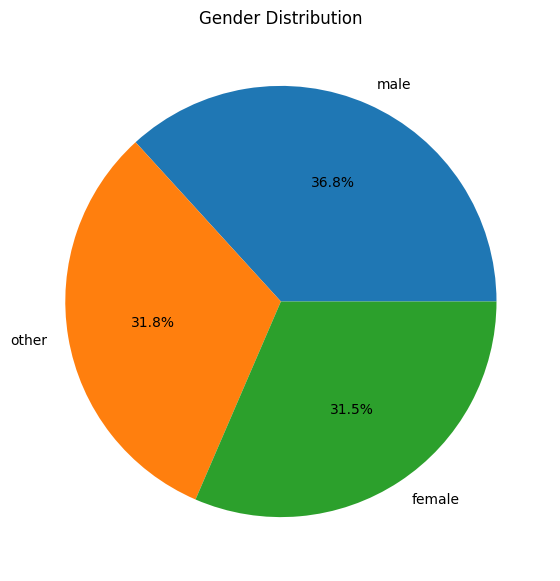

In [ ]:
#pie chart -Gender Distribution
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

Interpretation:The gender distribution chart shows the proportion of users across different gender categories. It helps identify which gender has the highest representation and whether the dataset is relatively balanced across genders.

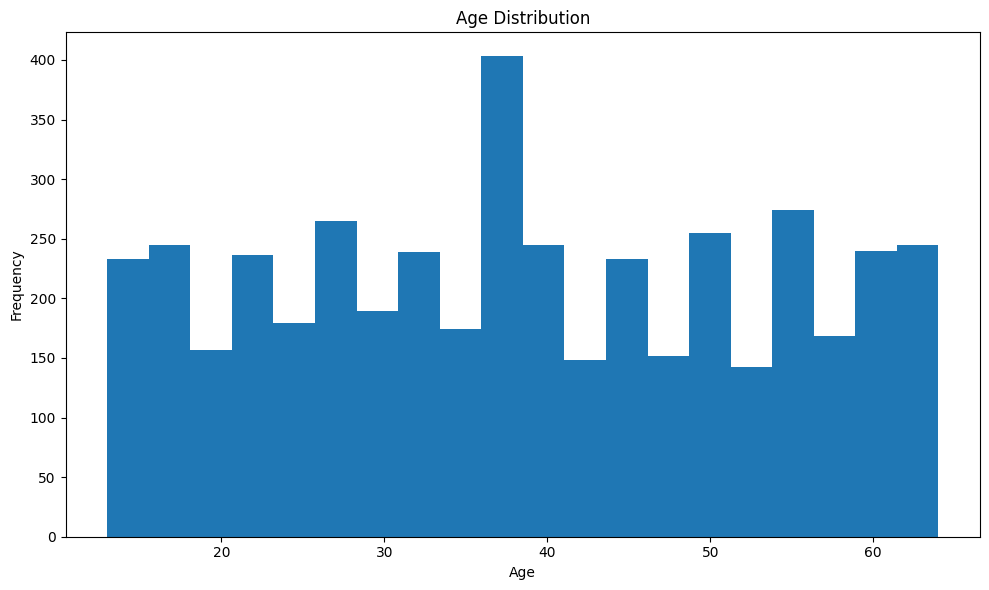

In [ ]:
#Histogram: age
plt.figure(figsize=(10, 6))

plt.hist(
    df["age"],
    bins=20
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Interpretation:
The histogram shows the distribution of users across different age groups. The users are spread across the age range of 13 to 64 years, with some age groups having higher frequencies than others. Overall, the age values are fairly distributed across the dataset

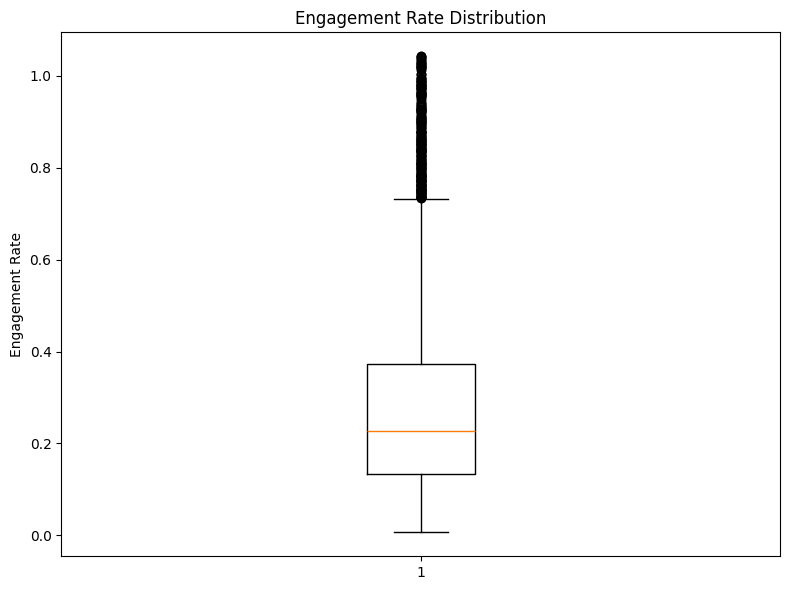

In [ ]:
#Box: engagement rate
plt.figure(figsize=(8, 6))

plt.boxplot(
    df["engagement_rate"].dropna()
)

plt.title("Engagement Rate Distribution")
plt.ylabel("Engagement Rate")

plt.tight_layout()
plt.show()

Interpretation:
The box plot shows that most posts have relatively low to moderate engagement rates, while a small number of posts have unusually high engagement rates. These extreme values are identified as outliers using the IQR method

# **Seaborn**

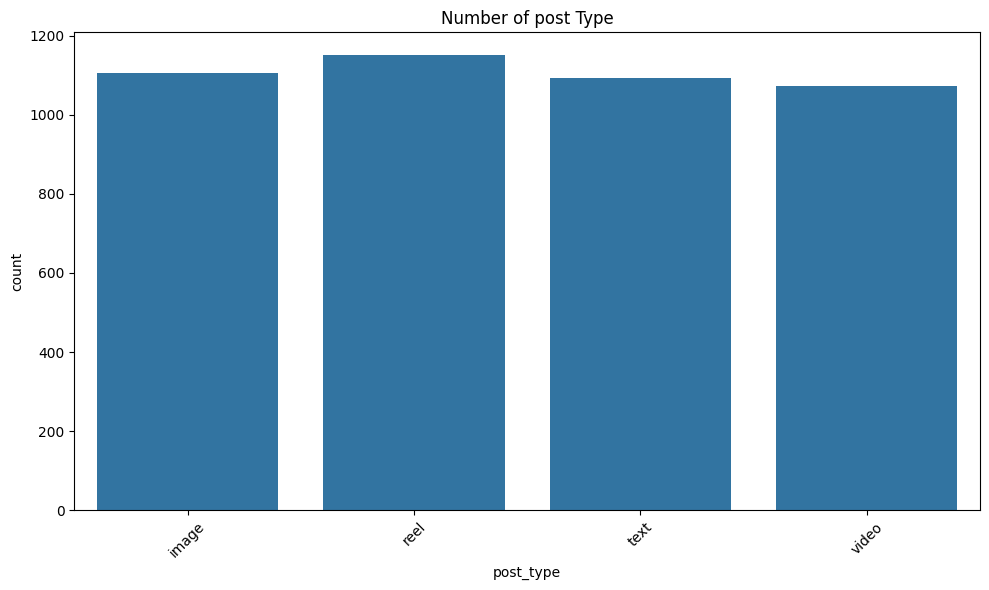

In [ ]:
#Count plot: post type
plt.figure(figsize=(10,6))

sns.countplot(data=df,x="post_type")

plt.title("Number of post Type")
plt.xlabel("post_type")
plt.ylabel("count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Interpretation**
The number of posts is fairly evenly distributed across all post types. Reel and image posts have slightly higher counts, while video posts have the lowest count. Overall, there is no major imbalance among the different post types.

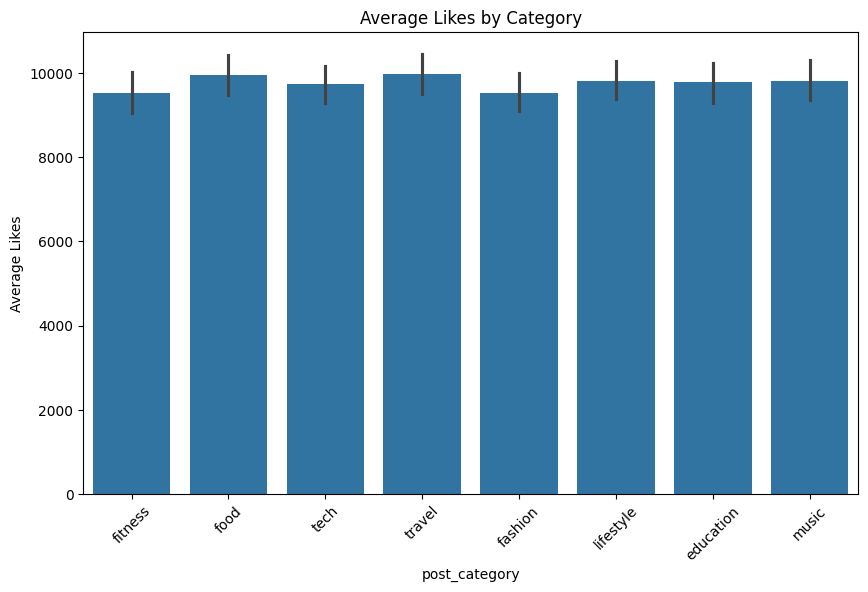

In [ ]:
#Bar Plot-Average Like by post_category
plt.figure(figsize=(10, 6))

sns.barplot(
    x="post_category",
    y="likes",
    data=df
)

plt.title("Average Likes by Category")
plt.xlabel("post_category")
plt.ylabel("Average Likes")

plt.xticks(rotation=45)
plt.show()






**Interpretation:**
Food category has the highest average likes, while Fashion has the lowest average likes. This shows that posts in different categories receive different levels of engagement

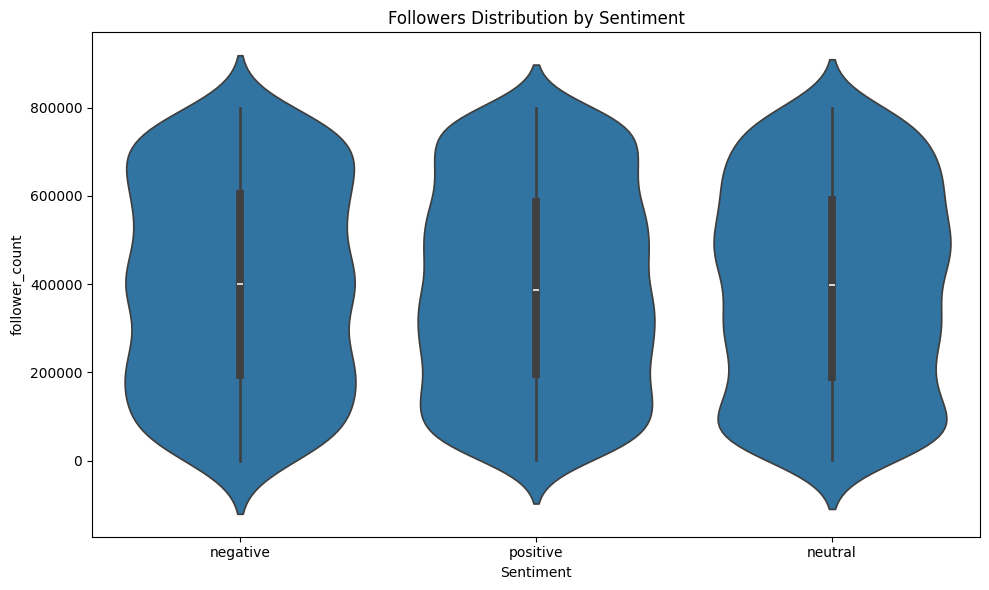

In [ ]:
#violin Plot-follower_count vs sentiment

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="sentiment",
    y="follower_count"
)

plt.title("Followers Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("follower_count")

plt.tight_layout()
plt.show()

**Interpretation**:The violin plot shows that follower counts are widely distributed across negative, positive, and neutral sentiments. The distributions are broadly similar, indicating that follower count varies considerably within each sentiment category.

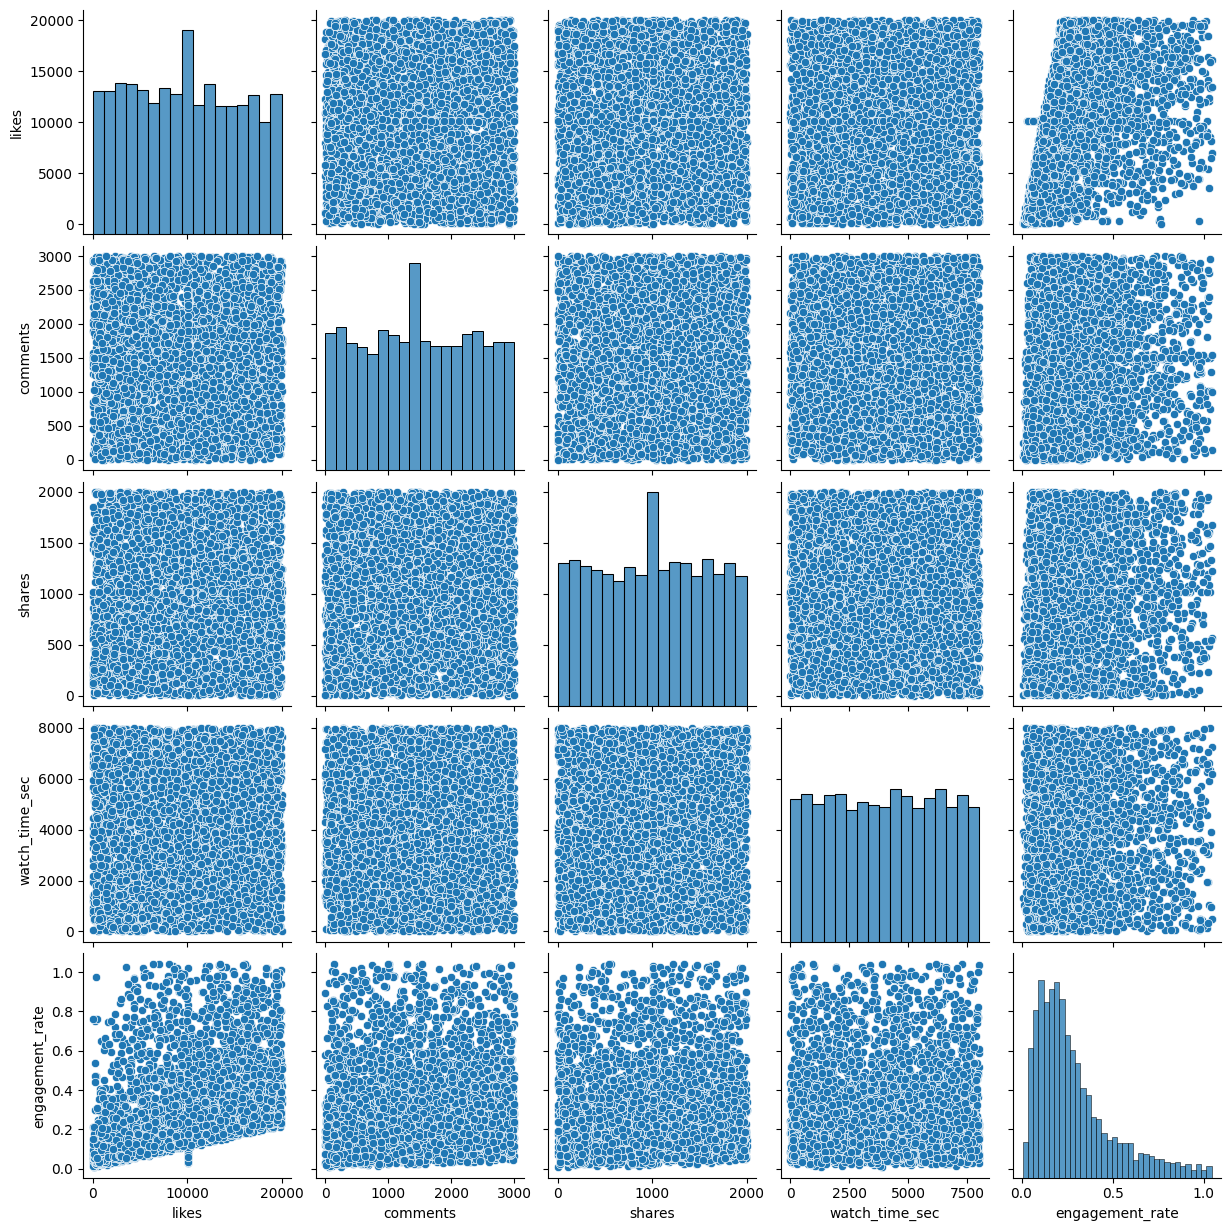

In [ ]:
pair_columns = [
    "likes",
    "comments",
    "shares",
    "watch_time_sec",
    "engagement_rate"
]

sns.pairplot(
    df[pair_columns].dropna()
)

plt.show()

# Interpretation:
The pair plot shows the distribution and relationships among likes, comments, shares, watch time, and engagement rate. The diagonal histograms show the distribution of each variable, while the scatter plots show their relationships. Most variables are widely distributed, and no very strong linear relationship is clearly visible between most variables. The engagement rate shows a right-skewed distribution, with most values concentrated at the lower range. Overall, the pair plot helps identify patterns, distributions, and possible relationships among the numerical variables

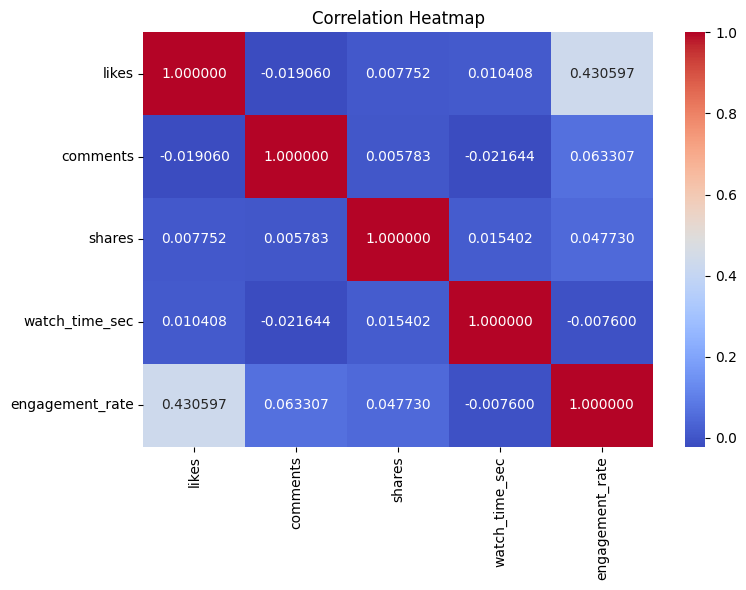

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[pair_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt="2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

**Interpretation**:The correlation heatmap shows that likes have a moderate positive relationship with engagement rate (0.43), while comments, shares, and watch time have very weak or almost no linear relationship with engagement rate

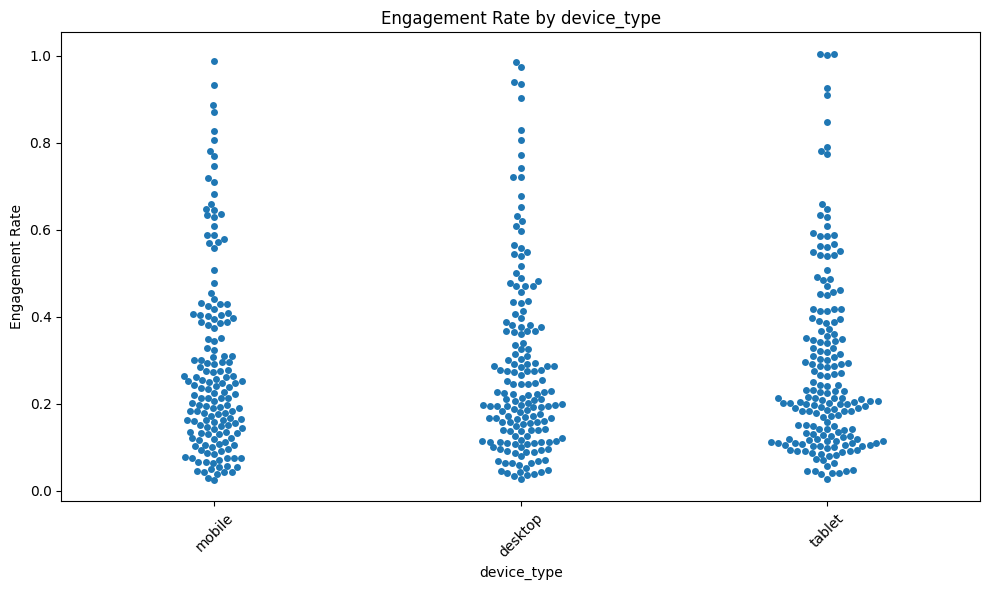

In [ ]:
#Swarmplot Engagement vs device_type
sample_df = df.sample(
    min(500, len(df)),
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.swarmplot(
    data=sample_df,
    x="device_type",
    y="engagement_rate"
)

plt.title("Engagement Rate by device_type")
plt.xlabel("device_type")
plt.ylabel("Engagement Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation**:The swarm plot shows the distribution of engagement rate across different devices. Most engagement rate values are concentrated between 0.1 and 0.3 for all devices. Mobile, desktop, and tablet show a similar overall distribution, with a few higher engagement-rate observations.

# **Plotly (Interactive)**


In [ ]:
df=df.copy()
df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")



In [ ]:
daily_plot = df.groupby(
    df["posted_at"].dt.date
)["engagement_score"].mean().reset_index()

daily_plot.columns = ["date", "engagement_score"]

fig = px.line(
    daily_plot,
    x="date",
    y="engagement_score",
    title="Interactive Daily Engagement Trend"
)

fig.show()


Interpretation: The line chart shows the daily engagement score over time. The engagement score fluctuates considerably from day to day, with most values around 8K–12K. Some days show high peaks, while others show lower values. Overall, engagement remains fairly stable with a slight downward trend over the period

In [ ]:
import plotly.express as px

post_category_plot = df.groupby(
    "post_category"
)["likes"].mean().reset_index()

fig = px.bar(
    post_category_plot,
    x="post_category",
    y="likes",
    title="Average Likes by Category"
)

fig.show()

Interpretation: The bar chart shows the average number of likes received by each category. The average likes are different across categories, with some categories receiving more likes than others. Overall, the chart shows that category can influence the average number of likes.

In [ ]:
fig = px.scatter(
    df,
    x="impression_count",
    y="likes",
    size="engagement_score",
    color="sentiment",
    hover_data=["post_type", "post_category", "country"],
    title="Interactive Social Media Engagement"
)

fig.show()

Interpretation: The scatter plot shows the relationship between impressions and likes. In general, posts with higher impressions tend to receive more likes. However, the points are widely scattered, so impressions alone do not determine the number of likes.

# **Final Insights should include the following analysis**

● Content Performance

In [ ]:
#Which post types have the highest engagement?
post_type_result = df.groupby(
    "post_type"
)["engagement_rate"].mean().sort_values(
    ascending=False
)

post_type_result

,engagement_rate
post_type,
image,0.293954
text,0.289549
reel,0.286869
video,0.286758


In [ ]:
print(
    "Highest average engagement post type:",
    post_type_result.idxmax()
)

print(
    "Average engagement:",
    post_type_result.max()
)

Highest average engagement post type: image
Average engagement: 0.2939542813607595


In [ ]:
#Best-performing content category?
post_category_result = df.groupby(
    "post_category"
)["engagement_rate"].mean().sort_values(
    ascending=False
)

print(
    "Best-performing category:",
    post_category_result.idxmax()
)

print(
    "Average engagement:",
    post_category_result.max()
)

Best-performing category: education
Average engagement: 0.2997155407767857


In [ ]:
#Which countries have the highest average engagement rate?

post_category_result = df.groupby(
    "post_category"
)["engagement_rate"].mean().sort_values(
    ascending=False
)

print(
    "Best-performing category:",
    post_category_result.idxmax()
)

print(
    "Average engagement:",
    post_category_result.max()
)
country_result = df.groupby(
    "country"
)["engagement_rate"].mean().sort_values(
    ascending=False
)

country_result

Best-performing category: education
Average engagement: 0.2997155407767857


,engagement_rate
country,
Germany,0.314103
Canada,0.303091
Japan,0.291688
Brazil,0.291581
UAE,0.289751
UK,0.284181
Australia,0.284168
India,0.281964
USA,0.281701


In [ ]:
#How age affects engagement
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 25, 35, 45, 60, 100],
    labels=[
        "Under 18",
        "18-25",
        "26-35",
        "36-45",
        "46-60",
        "60+"
    ]
)

In [ ]:
age_engagement = df.groupby(
    "age_group",
    observed=True
)["engagement_rate"].mean()

age_engagement

,engagement_rate
age_group,
Under 18,0.301129
18-25,0.297918
26-35,0.292045
36-45,0.286866
46-60,0.283312
60+,0.278909


In [ ]:
#Performance difference for verified accounts
is_verified_result = df.groupby(
    "is_verified"
)["engagement_rate"].mean()

is_verified_result

,engagement_rate
is_verified,
False,0.292488
True,0.259001


In [ ]:
#Behavioral Insights
#Best time of day forimpression_count

df["posted_at"] = pd.to_datetime(df["posted_at"], errors="coerce")

df["hour"] = df["posted_at"].dt.hour

hourly_impression_count = df.groupby("hour")["impression_count"].mean().sort_values(ascending=False)

print(hourly_impression_count)

print("Best hour:", hourly_impression_count.idxmax())
print("Average impression_count:", hourly_impression_count.max())

hour
0    55581.162822
Name: impression_count, dtype: float64
Best hour: 0
Average impression_count: 55581.16282225237


In [ ]:
#Device device_type impact on watch_time_sec

device_type = df.groupby(
    "device_type"
)["watch_time_sec"].mean().sort_values(
    ascending=False
)

device_type

,watch_time_sec
device_type,
mobile,4077.102961
tablet,3972.656379
desktop,3929.182003


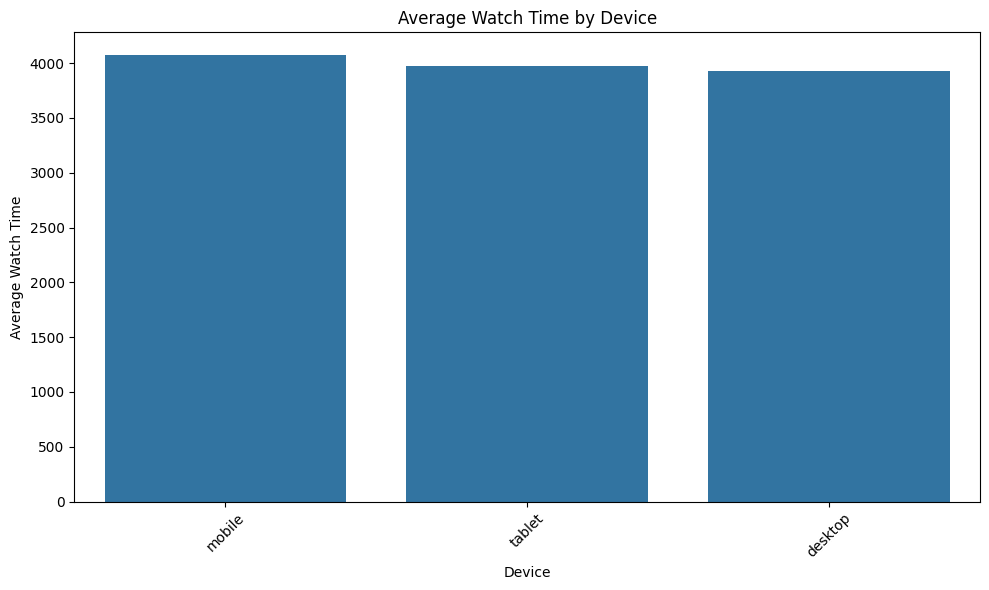

In [ ]:
device_watch = df.groupby(
    "device_type"
)["watch_time_sec"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=device_watch.index,
    y=device_watch.values
)

plt.title("Average Watch Time by Device")
plt.xlabel("Device")
plt.ylabel("Average Watch Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Interpretation:Desktop users have the highest average watch time, while mobile users have the lowest. This suggests that device type may influence how long users watch social media content.

In [ ]:
#Sentiment Analysis
#Which sentiment performs best
sentiment_result = df.groupby(
    "sentiment"
)["engagement_rate"].mean().sort_values(
    ascending=False
)

sentiment_result

,engagement_rate
sentiment,
neutral,0.294935
positive,0.288012
negative,0.283493


In [ ]:
#Behavior of negative/neutral sentiment posts
negative_neutral = df[
    df["sentiment"].isin(["negative", "neutral"])
]

negative_neutral.groupby(
    "sentiment"
)[
    ["likes", "comments", "shares", "watch_time_sec", "engagement_rate"]
].mean()

,likes,comments,shares,watch_time_sec,engagement_rate
sentiment,,,,,
negative,9817.489247,1513.324970,1000.442055,4020.391876,0.283493
neutral,9539.261448,1519.062038,995.188331,4001.724520,0.294935
